In [1]:
import numpy as np
import pyoti.sparse as oti
from jetgp.full_degp.degp import degp
import jetgp.utils as utils
from matplotlib import pyplot as plt

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_bases = 2
n_order = 1  # First-order derivatives only
grid_size = 5  # 5x5 grid = 25 points
test_resolution = 50
lower_bounds = [-3.0, -3.0]
upper_bounds = [3.0, 3.0]
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 42
np.random.seed(random_seed)

In [3]:
def true_function(X, alg=np):
    """
    2D test function:
    f(x1, x2) = sin(x1) * cos(x2) + 0.5 * x1 * x2
    """
    x1, x2 = X[:, 0], X[:, 1]
    return alg.sin(x1) * alg.cos(x2) + 0.5 * x1 * x2

In [4]:
def build_spatial_chain(X_train):
    """
    Build a greedy nearest-neighbor chain through all training points.
    """
    n_pts = len(X_train)
    visited = [False] * n_pts
    chain = [0]
    visited[0] = True

    for _ in range(n_pts - 1):
        current = chain[-1]
        dists = np.linalg.norm(X_train - X_train[current], axis=1)
        dists[visited] = np.inf
        nearest = np.argmin(dists)
        chain.append(nearest)
        visited[nearest] = True

    return chain

In [5]:
def assign_cycling_derivatives(chain, n_bases=2):
    """
    Assign derivatives cycling through dimensions along the chain.

    For 2D:
    - position 0, 2, 4, ... -> d/dx1
    - position 1, 3, 5, ... -> d/dx2
    """
    derivative_groups = [[] for _ in range(n_bases)]

    for pos, pt_idx in enumerate(chain):
        group = pos % n_bases
        derivative_groups[group].append(pt_idx)

    return derivative_groups

In [6]:
def generate_grid_points(grid_size, lower_bounds, upper_bounds):
    """Generate training points on a regular grid."""
    x1 = np.linspace(lower_bounds[0], upper_bounds[0], grid_size)
    x2 = np.linspace(lower_bounds[1], upper_bounds[1], grid_size)
    X1_grid, X2_grid = np.meshgrid(x1, x2)
    X_train = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    return X_train


def evaluate_function_with_derivatives(X_train, n_bases, n_order):
    """Evaluate function and all first-order derivatives at training points."""
    X_train_pert = oti.array(X_train)
    for i in range(n_bases):
        X_train_pert[:, i] += oti.e(i + 1, order=n_order)

    y_train_hc = true_function(X_train_pert, alg=oti)

    y_values = y_train_hc.real
    all_derivatives = {}
    for i in range(n_bases):
        all_derivatives[i + 1] = y_train_hc.get_deriv([[i + 1, 1]])

    return y_values, all_derivatives

In [7]:
def setup_cycling_degp(X_train, y_values, all_derivatives, derivative_groups):
    """
    Set up DEGP with cycling derivative assignment.
    Each point contributes exactly one derivative observation.
    """
    # Function values at all points
    y_train_list = [y_values.reshape(-1, 1)]

    # Each derivative only at its assigned points
    for i, group_pts in enumerate(derivative_groups):
        var_idx = i + 1
        y_train_list.append(all_derivatives[var_idx][group_pts].reshape(-1, 1))

    # Derivative indices for first-order derivatives
    der_indices = [
        [[[1, 1]], [[2, 1]]]
    ]

    # Specify which points have which derivatives
    derivative_locations = [list(group) for group in derivative_groups]

    return y_train_list, der_indices, derivative_locations

In [8]:
def setup_full_degp(X_train, y_values, all_derivatives):
    """
    Set up DEGP with full derivatives at all points (baseline).
    """
    n_pts = len(X_train)
    all_points = list(range(n_pts))

    y_train_list = [y_values.reshape(-1, 1)]
    for i in range(1, 3):
        y_train_list.append(all_derivatives[i].reshape(-1, 1))

    der_indices = [
        [[[1, 1]], [[2, 1]]]
    ]

    derivative_locations = [all_points, all_points]

    return y_train_list, der_indices, derivative_locations

In [9]:
def train_model(X_train, y_train_list, n_order, n_bases, der_indices,
                derivative_locations, normalize_data, kernel, kernel_type):
    """Train DEGP model with PSO optimization."""
    gp_model = degp(
        X_train, y_train_list, n_order, n_bases,
        der_indices,
        derivative_locations=derivative_locations,
        normalize=normalize_data,
        kernel=kernel, kernel_type=kernel_type
    )

    params = gp_model.optimize_hyperparameters(
        optimizer='pso',
        pop_size=150,
        n_generations=15,
        local_opt_every=15,
        debug=True
    )

    return gp_model, params

In [10]:
def verify_interpolation(gp_model, params, X_train, y_train_list,
                         derivative_locations, model_name="Model"):
    """Verify that the model correctly interpolates training data."""
    print(f"\nInterpolation Verification for {model_name}")
    print("-" * 50)

    y_pred, _ = gp_model.predict(X_train, params, calc_cov=True, return_deriv=True)

    all_passed = True

    # Check function values
    y_func_true = y_train_list[0].flatten()
    y_func_pred = y_pred[0, :].flatten()
    func_error = np.abs(y_func_pred - y_func_true)
    func_max_err = np.max(func_error)
    func_pass = func_max_err < 1e-4
    all_passed = all_passed and func_pass

    status = "✓" if func_pass else "✗"
    print(f"{status} Function values:  max_err = {func_max_err:.2e}")

    # Check derivatives
    derivative_names = ["∂f/∂x₁", "∂f/∂x₂"]

    for i, (deriv_locs, name) in enumerate(zip(derivative_locations, derivative_names)):
        y_deriv_true = y_train_list[i + 1].flatten()
        y_deriv_pred = y_pred[i + 1, :].flatten()[deriv_locs]

        deriv_error = np.abs(y_deriv_pred - y_deriv_true)
        deriv_max_err = np.max(deriv_error)
        deriv_pass = deriv_max_err < 1e-4
        all_passed = all_passed and deriv_pass

        status = "✓" if deriv_pass else "✗"
        print(f"{status} {name} (n={len(deriv_locs):2d}): max_err = {deriv_max_err:.2e}")

    print("-" * 50)
    print(f"{'✓ ALL PASSED' if all_passed else '✗ SOME FAILED'}")

    return all_passed

In [11]:
def evaluate_on_grid(gp_model, params, lower_bounds, upper_bounds, resolution):
    """Evaluate model on a fine grid."""
    x1 = np.linspace(lower_bounds[0], upper_bounds[0], resolution)
    x2 = np.linspace(lower_bounds[1], upper_bounds[1], resolution)
    X1_grid, X2_grid = np.meshgrid(x1, x2)
    X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

    y_pred, y_var = gp_model.predict(X_test, params, calc_cov=True)
    y_true = true_function(X_test, alg=np)

    return {
        "X1_grid": X1_grid,
        "X2_grid": X2_grid,
        "y_true": y_true.reshape(X1_grid.shape),
        "y_pred": y_pred.reshape(X1_grid.shape),
        "y_var": y_var.reshape(X1_grid.shape),
        "nrmse": utils.nrmse(y_true, y_pred)
    }

In [12]:
def visualize_derivative_assignment(X_train, chain, derivative_groups):
    """Visualize the chain and derivative assignments on the 2D grid."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    colors = ['blue', 'red']
    markers = ['o', 's']
    labels = [r'$\partial f/\partial x_1$', r'$\partial f/\partial x_2$']

    # Panel 1: Chain path
    ax = axes[0]
    chain_coords = X_train[chain]
    ax.plot(chain_coords[:, 0], chain_coords[:, 1], 'k-', alpha=0.5, linewidth=1.5)
    ax.scatter(X_train[:, 0], X_train[:, 1], c='gray', s=80, edgecolor='k', zorder=5)
    ax.scatter(*X_train[chain[0]], c='green', s=150, marker='*', zorder=10, label='Start')
    ax.scatter(*X_train[chain[-1]], c='red', s=150, marker='X', zorder=10, label='End')
    for i, idx in enumerate(chain):
        ax.annotate(str(i), X_train[idx] + np.array([0.1, 0.1]), fontsize=7, alpha=0.7)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Nearest-Neighbor Chain Path')
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Panel 2: Derivative assignments
    ax = axes[1]
    for group, color, marker, label in zip(derivative_groups, colors, markers, labels):
        ax.scatter(X_train[group, 0], X_train[group, 1],
                   c=color, s=120, edgecolor='k', marker=marker, label=label)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Derivative Assignment\n(1 derivative per point)')
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Panel 3: Combined view
    ax = axes[2]
    chain_coords = X_train[chain]
    ax.plot(chain_coords[:, 0], chain_coords[:, 1], 'k-', alpha=0.3, linewidth=1)
    for group, color, marker, label in zip(derivative_groups, colors, markers, labels):
        ax.scatter(X_train[group, 0], X_train[group, 1],
                   c=color, s=120, edgecolor='k', marker=marker, label=label)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Chain + Derivative Pattern')
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [13]:
def plot_results_comparison(X_train, results_cycling, results_full, derivative_groups):
    """Compare cycling vs full derivative strategies."""
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    colors = ['blue', 'red']
    markers = ['o', 's']

    # Row 1: Cycling strategy
    im0 = axes[0, 0].contourf(results_cycling["X1_grid"], results_cycling["X2_grid"],
                               results_cycling["y_true"], levels=30, cmap="viridis")
    for i, (group, color, marker) in enumerate(zip(derivative_groups, colors, markers)):
        axes[0, 0].scatter(X_train[group, 0], X_train[group, 1],
                           c=color, s=60, edgecolor='k', marker=marker)
    axes[0, 0].set_title("True Function")
    axes[0, 0].set_ylabel("Cycling\n(1 deriv/pt)")
    plt.colorbar(im0, ax=axes[0, 0])

    im1 = axes[0, 1].contourf(results_cycling["X1_grid"], results_cycling["X2_grid"],
                               results_cycling["y_pred"], levels=30, cmap="viridis")
    for i, (group, color, marker) in enumerate(zip(derivative_groups, colors, markers)):
        axes[0, 1].scatter(X_train[group, 0], X_train[group, 1],
                           c=color, s=60, edgecolor='k', marker=marker)
    axes[0, 1].set_title(f"Prediction (NRMSE: {results_cycling['nrmse']:.4f})")
    plt.colorbar(im1, ax=axes[0, 1])

    error_cycling = np.abs(results_cycling["y_true"] - results_cycling["y_pred"])
    im2 = axes[0, 2].contourf(results_cycling["X1_grid"], results_cycling["X2_grid"],
                               error_cycling, levels=30, cmap="magma")
    for i, (group, color, marker) in enumerate(zip(derivative_groups, colors, markers)):
        axes[0, 2].scatter(X_train[group, 0], X_train[group, 1],
                           c=color, s=60, edgecolor='k', marker=marker)
    axes[0, 2].set_title(f"Absolute Error (Max: {error_cycling.max():.3f})")
    plt.colorbar(im2, ax=axes[0, 2])

    im3 = axes[0, 3].contourf(results_cycling["X1_grid"], results_cycling["X2_grid"],
                               np.sqrt(results_cycling["y_var"]), levels=30, cmap="plasma")
    for i, (group, color, marker) in enumerate(zip(derivative_groups, colors, markers)):
        axes[0, 3].scatter(X_train[group, 0], X_train[group, 1],
                           c=color, s=60, edgecolor='k', marker=marker)
    axes[0, 3].set_title("Std Dev (Uncertainty)")
    plt.colorbar(im3, ax=axes[0, 3])

    # Row 2: Full derivatives
    im4 = axes[1, 0].contourf(results_full["X1_grid"], results_full["X2_grid"],
                               results_full["y_true"], levels=30, cmap="viridis")
    axes[1, 0].scatter(X_train[:, 0], X_train[:, 1], c='white', s=60, edgecolor='k')
    axes[1, 0].set_title("True Function")
    axes[1, 0].set_ylabel("Full\n(2 deriv/pt)")
    axes[1, 0].set_xlabel("$x_1$")
    plt.colorbar(im4, ax=axes[1, 0])

    im5 = axes[1, 1].contourf(results_full["X1_grid"], results_full["X2_grid"],
                               results_full["y_pred"], levels=30, cmap="viridis")
    axes[1, 1].scatter(X_train[:, 0], X_train[:, 1], c='white', s=60, edgecolor='k')
    axes[1, 1].set_title(f"Prediction (NRMSE: {results_full['nrmse']:.4f})")
    axes[1, 1].set_xlabel("$x_1$")
    plt.colorbar(im5, ax=axes[1, 1])

    error_full = np.abs(results_full["y_true"] - results_full["y_pred"])
    im6 = axes[1, 2].contourf(results_full["X1_grid"], results_full["X2_grid"],
                               error_full, levels=30, cmap="magma")
    axes[1, 2].scatter(X_train[:, 0], X_train[:, 1], c='white', s=60, edgecolor='k')
    axes[1, 2].set_title(f"Absolute Error (Max: {error_full.max():.3f})")
    axes[1, 2].set_xlabel("$x_1$")
    plt.colorbar(im6, ax=axes[1, 2])

    im7 = axes[1, 3].contourf(results_full["X1_grid"], results_full["X2_grid"],
                               np.sqrt(results_full["y_var"]), levels=30, cmap="plasma")
    axes[1, 3].scatter(X_train[:, 0], X_train[:, 1], c='white', s=60, edgecolor='k')
    axes[1, 3].set_title("Std Dev (Uncertainty)")
    axes[1, 3].set_xlabel("$x_1$")
    plt.colorbar(im7, ax=axes[1, 3])

    plt.suptitle("Comparison: Cycling (1 deriv/pt) vs Full (2 deriv/pt)",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Grid: 5x5 = 25 points
d/dx1 assigned to: 13 points
d/dx2 assigned to: 12 points


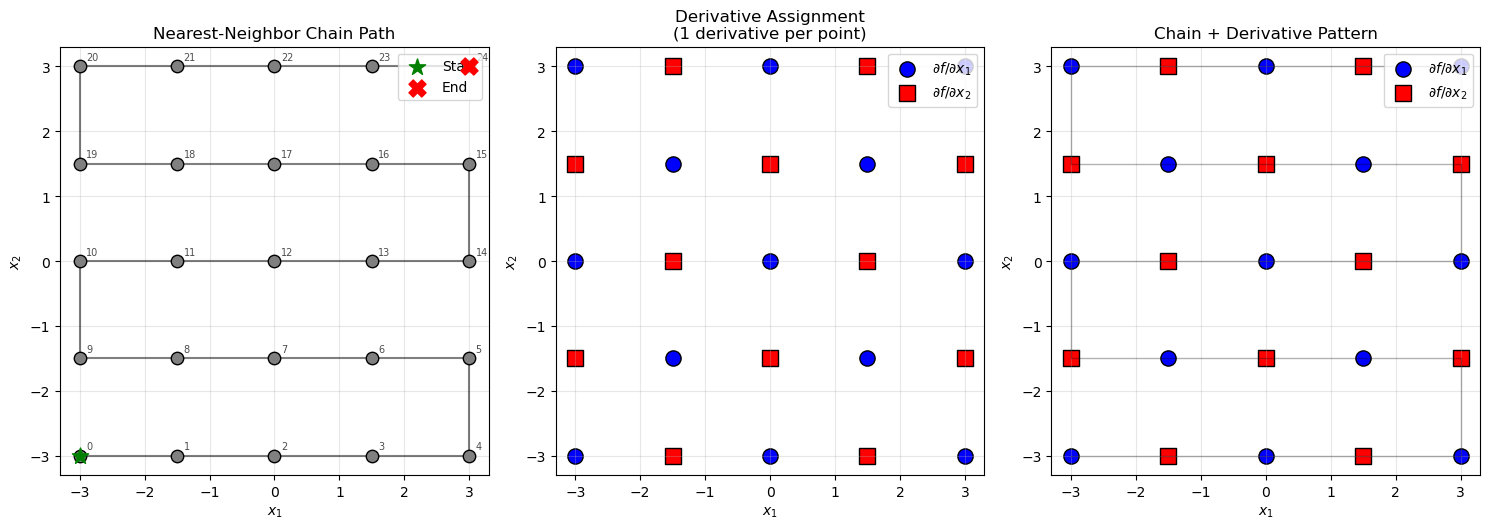

In [14]:
# Generate training points on grid
X_train = generate_grid_points(grid_size, lower_bounds, upper_bounds)
print(f"Grid: {grid_size}x{grid_size} = {len(X_train)} points")

# Evaluate function and derivatives
y_values, all_derivatives = evaluate_function_with_derivatives(X_train, n_bases, n_order)

# Build spatial chain and assign derivatives
chain = build_spatial_chain(X_train)
derivative_groups = assign_cycling_derivatives(chain, n_bases)
print(f"d/dx1 assigned to: {len(derivative_groups[0])} points")
print(f"d/dx2 assigned to: {len(derivative_groups[1])} points")

# Visualize the chain and derivative assignments
visualize_derivative_assignment(X_train, chain, derivative_groups)

In [15]:
# Setup and train cycling model
print("Training CYCLING derivative model...")
y_train_cyc, der_indices_cyc, der_locs_cyc = setup_cycling_degp(
    X_train, y_values, all_derivatives, derivative_groups
)

total_obs_cyc = sum(y.shape[0] for y in y_train_cyc)
print(f"Total observations: {total_obs_cyc}")

gp_model_cyc, params_cyc = train_model(
    X_train, y_train_cyc, n_order, n_bases, der_indices_cyc, der_locs_cyc,
    normalize_data, kernel, kernel_type
)

verify_interpolation(gp_model_cyc, params_cyc, X_train, y_train_cyc,
                     der_locs_cyc, model_name="Cycling DEGP")

Training CYCLING derivative model...
Total observations: 50
Best after iteration 1: [  1.85452949   0.18777149  -0.08631969 -10.45224132] 98.74482077494017


Best after iteration 2: [  1.85452949   0.18777149  -0.08631969 -10.45224132] 98.74482077494017
New best for swarm at iteration 3: [ -0.13887979   0.24580124  -0.19474382 -14.28207275] 71.94761700249268
New best for swarm at iteration 3: [ 0.08444039  0.55689953  0.06281487 -8.87962525] 54.423829925036536
New best for swarm at iteration 3: [-0.18069788  0.45388479  0.00482674 -3.56275843] 52.452549389014514
New best for swarm at iteration 3: [  0.16220763   0.15148297   0.11674397 -10.99848752] 34.34047018961147
Best after iteration 3: [  0.16220763   0.15148297   0.11674397 -10.99848752] 34.34047018961147
New best for swarm at iteration 4: [ -0.17752439   0.41610293   0.27300775 -11.69021138] 21.49182560285345
Best after iteration 4: [ -0.17752439   0.41610293   0.27300775 -11.69021138] 21.49182560285345
New best for swarm at iteration 5: [ -0.15981761   0.30507947   0.35109238 -10.22997986] 14.811220194212694
New best for swarm at iteration 5: [ 2.11172912e-01  4.18101933e-03 -1.1489

Best after iteration 8: [-0.07554074 -0.16388112  0.45578704 -9.80433253] -27.81480666028778
New best for swarm at iteration 9: [ -0.0624913   -0.07027203   0.31725272 -10.5821315 ] -27.999703668419208
Best after iteration 9: [ -0.0624913   -0.07027203   0.31725272 -10.5821315 ] -27.999703668419208
New best for swarm at iteration 10: [ -0.03730175  -0.12943498   0.40000634 -10.44310022] -28.083012816570736
New best for swarm at iteration 10: [ -0.08927535  -0.16418562   0.54083949 -11.33268907] -28.32664712552829
New best for swarm at iteration 10: [-0.0858461  -0.11861646  0.4930095  -9.82232864] -29.211774107110266
Best after iteration 10: [-0.0858461  -0.11861646  0.4930095  -9.82232864] -29.211774107110266
New best for swarm at iteration 11: [ -0.09315205  -0.10998818   0.33506919 -10.27644311] -29.56765880078938
New best for swarm at iteration 11: [ -0.07854068  -0.11841099   0.37215425 -10.21434656] -30.89802763273925
Best after iteration 11: [ -0.07854068  -0.11841099   0.372154

Best after iteration 14: [ -0.08837006  -0.12026812   0.41426867 -10.05162042] -31.001351148270423
New best for swarm at iteration 15: [ -0.08717844  -0.11780201   0.40196018 -10.03909854] -31.007980443845803


Gradient refinement improved
Best after iteration 15: [ -0.08542613  -0.11866614   0.40406801 -10.03909854] -31.016103099579674
Stopping: maximum iterations reached --> 15

Interpolation Verification for Cycling DEGP
--------------------------------------------------
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]
✓ Function values:  max_err = 2.09e-12
✓ ∂f/∂x₁ (n=13): max_err = 4.56e-13
✓ ∂f/∂x₂ (n=12): max_err = 2.42e-13
--------------------------------------------------
✓ ALL PASSED


True

In [16]:
# Setup and train full model
print("Training FULL derivative model...")
y_train_full, der_indices_full, der_locs_full = setup_full_degp(
    X_train, y_values, all_derivatives
)

total_obs_full = sum(y.shape[0] for y in y_train_full)
print(f"Total observations: {total_obs_full}")

gp_model_full, params_full = train_model(
    X_train, y_train_full, n_order, n_bases, der_indices_full, der_locs_full,
    normalize_data, kernel, kernel_type
)

verify_interpolation(gp_model_full, params_full, X_train, y_train_full,
                     der_locs_full, model_name="Full DEGP")

Training FULL derivative model...
Total observations: 75
New best for swarm at iteration 1: [  0.39510298  -0.25416288   0.4274083  -10.05280926] -48.239500374624654
New best for swarm at iteration 1: [  0.21569409  -0.11745501   0.35928068 -13.88682892] -63.41923596265444
Best after iteration 1: [  0.21569409  -0.11745501   0.35928068 -13.88682892] -63.41923596265444


Best after iteration 2: [  0.21569409  -0.11745501   0.35928068 -13.88682892] -63.41923596265444
Best after iteration 3: [  0.21569409  -0.11745501   0.35928068 -13.88682892] -63.41923596265444


Best after iteration 4: [  0.21569409  -0.11745501   0.35928068 -13.88682892] -63.41923596265444
New best for swarm at iteration 5: [ 1.25731122e-02  7.28076225e-02  2.90557622e-01 -1.30560270e+01] -63.78212120674455
New best for swarm at iteration 5: [  0.13881812  -0.20724075   0.41402476 -12.49759423] -107.90502201882923
Best after iteration 5: [  0.13881812  -0.20724075   0.41402476 -12.49759423] -107.90502201882923
New best for swarm at iteration 6: [ -0.07252981   0.03206539   0.337447   -12.32099848] -111.58586044622346
Best after iteration 6: [ -0.07252981   0.03206539   0.337447   -12.32099848] -111.58586044622346
New best for swarm at iteration 7: [ -0.12616711  -0.03681147   0.39077797 -12.2211565 ] -151.76665710578305
Best after iteration 7: [ -0.12616711  -0.03681147   0.39077797 -12.2211565 ] -151.76665710578305
New best for swarm at iteration 8: [ -0.12349867  -0.11658907   0.3909012  -14.08068093] -157.89113192637257


Best after iteration 8: [ -0.12349867  -0.11658907   0.3909012  -14.08068093] -157.89113192637257
New best for swarm at iteration 9: [ -0.13349205  -0.08616672   0.42276907 -11.7722493 ] -162.73547534151828
Best after iteration 9: [ -0.13349205  -0.08616672   0.42276907 -11.7722493 ] -162.73547534151828


Best after iteration 10: [ -0.13349205  -0.08616672   0.42276907 -11.7722493 ] -162.73547534151828
New best for swarm at iteration 11: [ -0.14820989  -0.07820284   0.48294627 -13.36023341] -163.20792850907605
New best for swarm at iteration 11: [ -0.14268017  -0.09584572   0.48024217 -12.5687813 ] -164.5344621416715
Best after iteration 11: [ -0.14268017  -0.09584572   0.48024217 -12.5687813 ] -164.5344621416715
New best for swarm at iteration 12: [ -0.14254449  -0.11103722   0.50174258 -12.00506167] -164.63103057549927
Best after iteration 12: [ -0.14254449  -0.11103722   0.50174258 -12.00506167] -164.63103057549927
New best for swarm at iteration 13: [ -0.15787097  -0.08951796   0.51519748 -11.95122066] -164.74916705458662
Best after iteration 13: [ -0.15787097  -0.08951796   0.51519748 -11.95122066] -164.74916705458662
New best for swarm at iteration 14: [ -0.1431213   -0.09968644   0.49104909 -11.99190122] -164.77376095936063
New best for swarm at iteration 14: [ -0.15706973  -0.09

New best for swarm at iteration 14: [ -0.14936857  -0.09373538   0.51010717 -11.92604423] -164.83007195403474
Best after iteration 14: [ -0.14936857  -0.09373538   0.51010717 -11.92604423] -164.83007195403474
New best for swarm at iteration 15: [ -0.14651564  -0.11308108   0.53130052 -12.00690449] -165.06909057142025


Local optimization did not improve:
Best after iteration 15: [ -0.14651564  -0.11308108   0.53130052 -12.00690449] -165.06909057142025
Stopping: maximum iterations reached --> 15

Interpolation Verification for Full DEGP
--------------------------------------------------
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]]]
✓ Function values:  max_err = 3.97e-10
✓ ∂f/∂x₁ (n=25): max_err = 7.21e-11
✓ ∂f/∂x₂ (n=25): max_err = 9.30e-11
--------------------------------------------------
✓ ALL PASSED


True

Cycling NRMSE:  0.000073
Full NRMSE:     0.000026
Ratio:          2.832


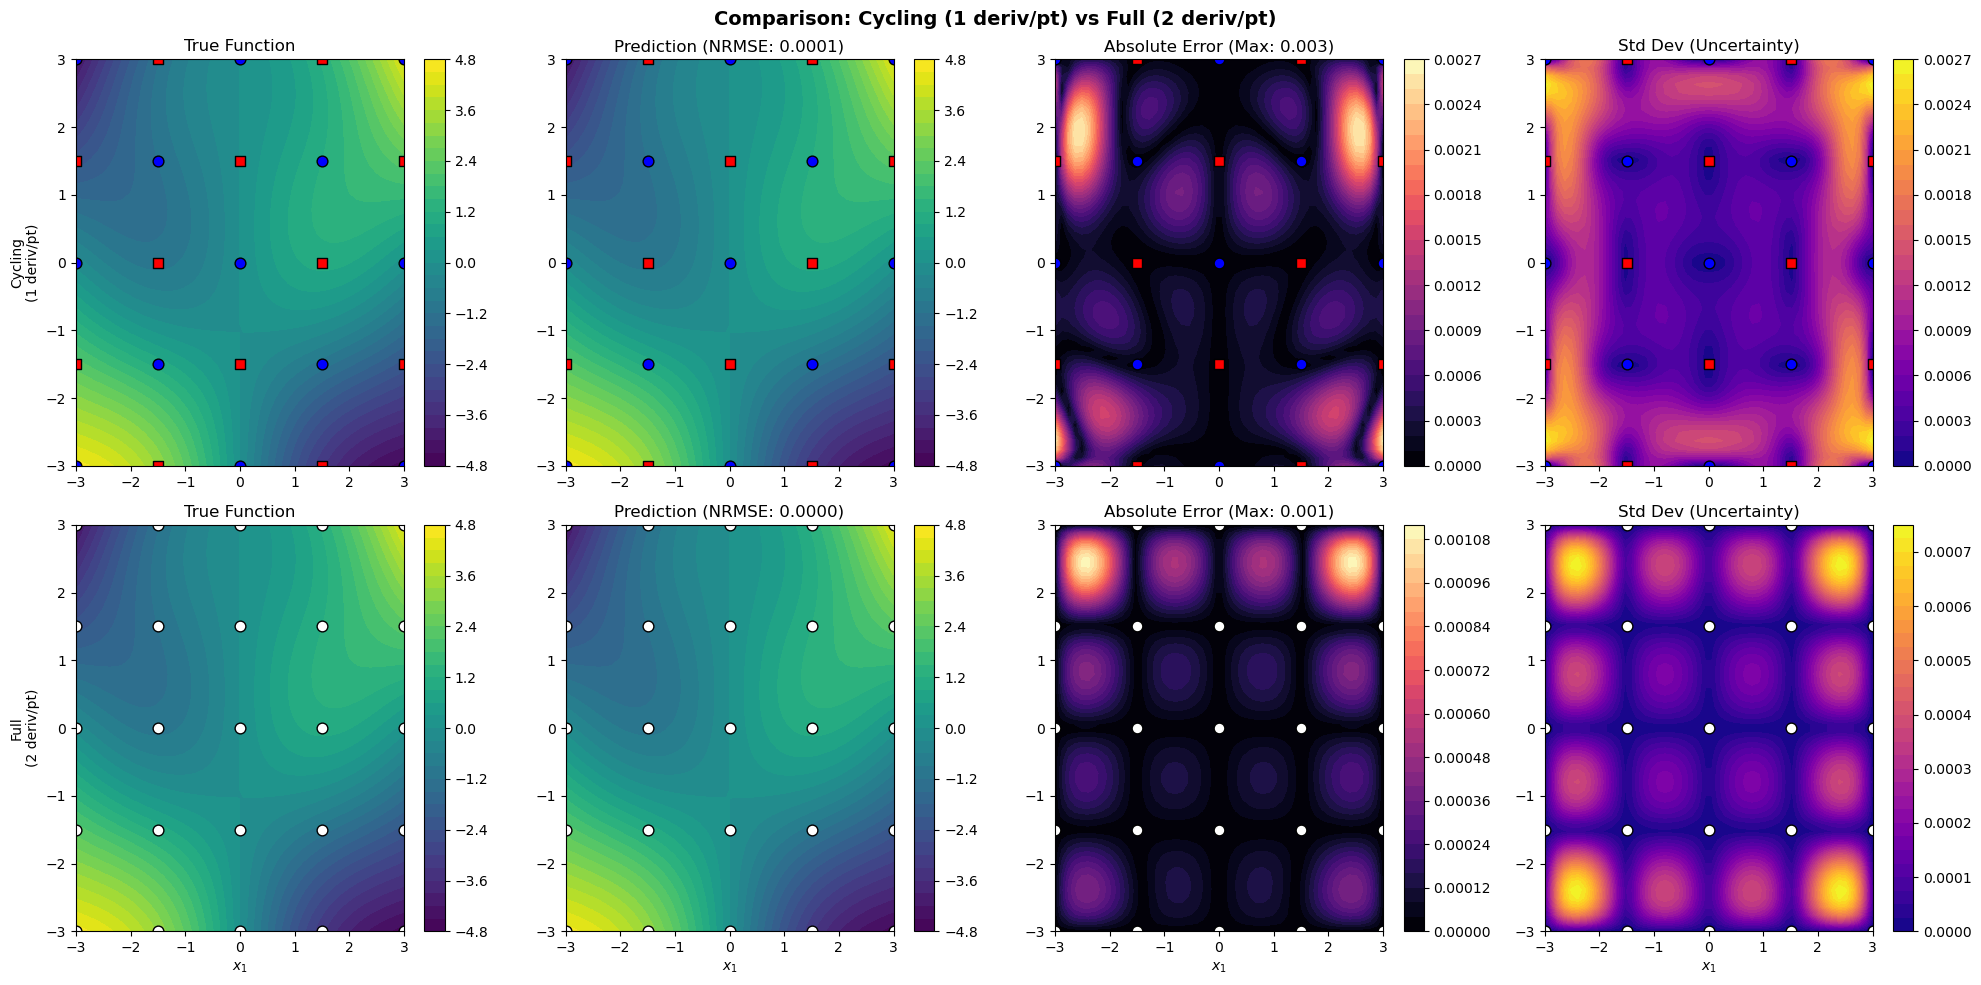

In [17]:
# Evaluate both models
results_cyc = evaluate_on_grid(gp_model_cyc, params_cyc, lower_bounds,
                                upper_bounds, test_resolution)
results_full = evaluate_on_grid(gp_model_full, params_full, lower_bounds,
                                 upper_bounds, test_resolution)

print(f"Cycling NRMSE:  {results_cyc['nrmse']:.6f}")
print(f"Full NRMSE:     {results_full['nrmse']:.6f}")
print(f"Ratio:          {results_cyc['nrmse']/results_full['nrmse']:.3f}")

# Plot comparison
plot_results_comparison(X_train, results_cyc, results_full, derivative_groups)

In [18]:
# Print summary
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Training points:              {len(X_train)}")
print(f"Dimensions:                   {n_bases}")
print()
print("Cycling strategy:")
print(f"  Function values:            {len(X_train)}")
print(f"  Derivative obs (1 per pt):  {len(X_train)}")
print(f"  Total observations:         {total_obs_cyc}")
print()
print("Full derivative strategy:")
print(f"  Function values:            {len(X_train)}")
print(f"  Derivative obs (2 per pt):  {len(X_train) * 2}")
print(f"  Total observations:         {total_obs_full}")
print()
print(f"Observation reduction:        {(1 - total_obs_cyc/total_obs_full)*100:.1f}%")
print(f"NRMSE ratio (cyc/full):       {results_cyc['nrmse']/results_full['nrmse']:.3f}")
print("=" * 60)

SUMMARY
Training points:              25
Dimensions:                   2

Cycling strategy:
  Function values:            25
  Derivative obs (1 per pt):  25
  Total observations:         50

Full derivative strategy:
  Function values:            25
  Derivative obs (2 per pt):  50
  Total observations:         75

Observation reduction:        33.3%
NRMSE ratio (cyc/full):       2.832
